In [11]:
#Name: Bogdan Gura
#Class: EMAT 32210 Section: 001

"""
Academic Honesty & AI Disclosure Statement
-------------------------------------------
As a student in EMAT 32210, I performed the data extraction, JSON parsing, 
and core pandas DataFrame manipulation myself, relying on standard online 
resources and Google searches/class materials to resolve syntax questions. However, I utilized 
Gemini AI specifically to assist in configuring the Matplotlib and Seaborn 
visualization code for the cumulative line graph in this section. This assistance 
was strictly limited to optimizing graph aesthetics, axis styling, and label 
annotations to present the findings clearly. I am fully aware of and compliant 
with the Kent State EMAT AI policy regarding generative tool usage and attribution, 
and I take full responsibility for reviewing, executing, and understanding all 
code within this notebook.
"""

import json
import pandas as pd

file_path_likes = "..\Raw Data\Instagram Likes\your_instagram_activity\likes\liked_posts.json"

# Load liked_posts.json
with open(file_path_likes, 'r', encoding='utf-8') as file:
    raw_likes_data = json.load(file)

In [13]:
parsed_likes = []

for entry in raw_likes_data:
    timestamp = entry.get('timestamp')
    fbid = entry.get('fbid')

    # Parse nested label_values structure
    for label_item in entry.get('label_values', []):
        # Extract owner username
        if label_item.get('title') == 'Owner':
            owner_dicts = label_item.get('dict', [])
            if owner_dicts:
                info_list = owner_dicts[0].get('dict', [])
                for info in info_list:
                    if info.get('label') == 'Username':
                        owner_username = info.get('value')
        
        # Extracting caption text for visualization
        if label_item.get('label') == 'Caption':
            caption = label_item.get('value')

    #Appending list
    parsed_likes.append({
        'timestamp_raw': timestamp,
        'owner_username': owner_username,
        'caption': caption,
        'fbid': fbid
    })

# Convert parsed data into a pandas DataFrame
df_likes = pd.DataFrame(parsed_likes)

# Extract and format standard datetime timestamp column
df_likes['timestamp'] = pd.to_datetime(df_likes['timestamp_raw'], unit='s')

# Reorder columns for tidiness
df_likes = df_likes[['timestamp', 'owner_username', 'caption', 'fbid', 'timestamp_raw']]

# Display first few rows
df_likes.head()

,timestamp,owner_username,caption,fbid,timestamp_raw
0,2025-11-13 22:06:19,guyhwachoi,#ìë¯¸ì´ì¬ë. It's a new drama. Please wat...,17900849751163553,1763071579
1,2025-11-12 03:49:12,dubai_homes_,Hwang Dong hyuk faced rejection from every stu...,18042534659471496,1762919352
2,2025-10-13 17:21:07,primevideosg,Playing a detective isnât the only thing heâ...,18007945091807613,1760376067
3,2025-09-28 18:18:26,thekentstater,If one had to describe an elevator in three wo...,17857230456514930,1759083506
4,2025-09-23 23:46:14,456_ljj,Lee Jung Jae throws the first pitch at the 202...,18097922428630384,1758671174


In [5]:
# Group by account name (owner_username) and count total likes per account
likes_per_account = (
    df_likes.groupby('owner_username')
    .size()
    .reset_index(name='like_count')
    .sort_values(by='like_count', ascending=False)
    .reset_index(drop=True)
)

# Display the summary table
likes_per_account

,owner_username,like_count
0,456_ljj,1
1,alexbelsermusic,1
2,andreww_mckenna,1
3,dubai_homes_,1
4,guyhwachoi,1
5,primevideosg,1
6,thekentstater,1


### Hypothesis

**Hypothesis:** 
Attending Kent State University directly increases my engagement with campus related content, so recent liked posts will include Kent State affiliated accounts.

Daily involvement in campus life exposes me to university events and local organizations, driving higher interaction with these pages on my feed.

In [15]:
file_path_following = file_path_following = "../Raw Data/Instagram Connections/connections/followers_and_following/following.json"

# Load following.json
with open(file_path_following, 'r', encoding='utf-8') as file:
    raw_following_data = json.load(file)

parsed_following = []

for item in raw_following_data.get('relationships_following', []):
    username = item.get('title')
    string_data = item.get('string_list_data', [])
    
    for sub_item in string_data:
        parsed_following.append({
            'account_username': username,
            'href': sub_item.get('href'),
            'timestamp_raw': sub_item.get('timestamp')
        })

# Create DataFrame
df_following = pd.DataFrame(parsed_following)

# Convert Unix timestamp to readable datetime
df_following['timestamp'] = pd.to_datetime(df_following['timestamp_raw'], unit='s')

# Sort chronologically
df_following = df_following.sort_values(by='timestamp').reset_index(drop=True)

# Reorder columns
df_following = df_following[['timestamp', 'account_username', 'href', 'timestamp_raw']]

# Display all rows
with pd.option_context('display.max_rows', None):

    display(df_following)

,timestamp,account_username,href,timestamp_raw
0,2024-08-22 19:00:42,oxana.gura.58,https://www.instagram.com/_u/oxana.gura.58,1724353242
1,2024-12-11 22:08:12,gura5276,https://www.instagram.com/_u/gura5276,1733954892
2,2024-12-11 22:09:42,guravika899,https://www.instagram.com/_u/guravika899,1733954982
3,2024-12-11 22:10:26,anatolii_gura,https://www.instagram.com/_u/anatolii_gura,1733955026
4,2025-02-02 15:07:12,valeriya.gura,https://www.instagram.com/_u/valeriya.gura,1738508832
5,2025-03-02 18:08:43,valentyngura,https://www.instagram.com/_u/valentyngura,1740938923
6,2025-03-03 20:19:32,squidgamenetflix,https://www.instagram.com/_u/squidgamenetflix,1741033172
7,2025-03-05 23:53:01,fishkeeper_guide,https://www.instagram.com/_u/fishkeeper_guide,1741218781
8,2025-04-05 23:41:55,dmytro_cherenkov,https://www.instagram.com/_u/dmytro_cherenkov,1743896515
9,2025-07-19 00:34:14,kentstate_sps,https://www.instagram.com/_u/kentstate_sps,1752885254


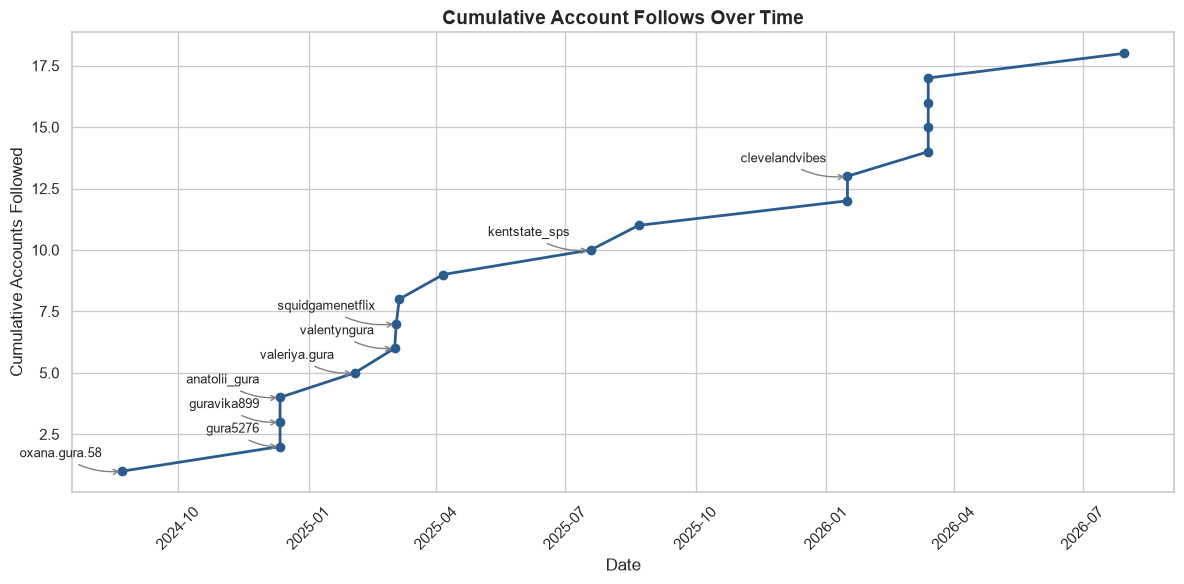

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization table
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Plot follow actions over time
plt.plot(df_following['timestamp'], range(1, len(df_following) + 1), marker='o', color='#2b5c8f', linewidth=2)

# Annotate notable account milestones
for i, row in df_following.iterrows():
    # Annotate specific accounts to highlight social vs institutional shifts
    if any(keyword in row['account_username'] for keyword in ['kentstate', 'cleveland', 'squid', 'gura']):
        plt.annotate(
            row['account_username'], 
            (row['timestamp'], i + 1),
            textcoords="offset points", 
            xytext=(-15, 10), 
            ha='right',
            fontsize=9,
            arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=.2", color="gray")
        )

plt.title('Cumulative Account Follows Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative Accounts Followed', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

**Conclusion:** 
While the hypothesis seems logical, the data proves it false. 
The vast majority of my account activity consists of close friends and relatives, with only a minimal Kent State footprint present in the dataset.